# Import Required Libraries
Import the necessary libraries, including NumPy, pandas, scikit-learn, and matplotlib.

In [5]:
# Import the necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load and Prepare the Dataset
Load the dataset using pandas and perform any necessary preprocessing steps such as handling missing values and encoding categorical variables.

In [6]:
# Load and Prepare the Dataset

# Load the dataset using pandas
data = pd.read_csv('BigMartSales Prediction/Train.csv')

# Display the first few rows of the dataset
data.head()

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Handle missing values (example: fill with mean for numerical columns)
data.Item_Weight = data.Item_Weight.fillna(data.Item_Weight.mean())
data.Outlet_Size = data.Outlet_Size.fillna(data.Outlet_Size.mode().iloc[0])
# Ensure all categorical columns are of type 'category'
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
	data[col] = data[col].astype('category')

# Encode categorical variables (example: using one-hot encoding)
data = pd.get_dummies(data, drop_first=True)

# Split the dataset into features and target variable
X = data.drop('Item_Outlet_Sales', axis=1)
y = data['Item_Outlet_Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Missing values in each column:
 Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


# Split the Dataset into Training and Testing Sets
Use scikit-learn's train_test_split function to split the dataset into training and testing sets.

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (6818, 1597) (6818,)
Testing set shape: (1705, 1597) (1705,)


# Train the k-NN Model
Train a k-NN model using scikit-learn's KNeighborsRegressor.

In [8]:
# Train the k-NN Model

# Initialize the k-NN regressor with a specified number of neighbors
n_neighbors = 5
knn = KNeighborsRegressor(n_neighbors=n_neighbors)

# Train the k-NN model using the training data
knn.fit(X_train, y_train)

# Predict the target values for the test set
y_pred = knn.predict(X_test)

# Calculate the Mean Squared Error (MSE) of the predictions
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with {n_neighbors} neighbors: {mse}")

Mean Squared Error with 5 neighbors: 1471665.2556201213


# Calculate Mean Squared Error (MSE)
Use scikit-learn's mean_squared_error function to calculate the MSE for the model's predictions on the test set.

In [9]:
# Calculate the Mean Squared Error (MSE)

# Predict the target values for the test set
y_pred = knn.predict(X_test)

# Calculate the Mean Squared Error (MSE) of the predictions
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with {n_neighbors} neighbors: {mse}")

Mean Squared Error with 5 neighbors: 1471665.2556201213


# Find the Best Value for n_neighbors
Use a loop to train and evaluate the k-NN model with different values of n_neighbors, and find the value that results in the lowest MSE.

Best n_neighbors: 11
Lowest Mean Squared Error: 1417399.4512712185


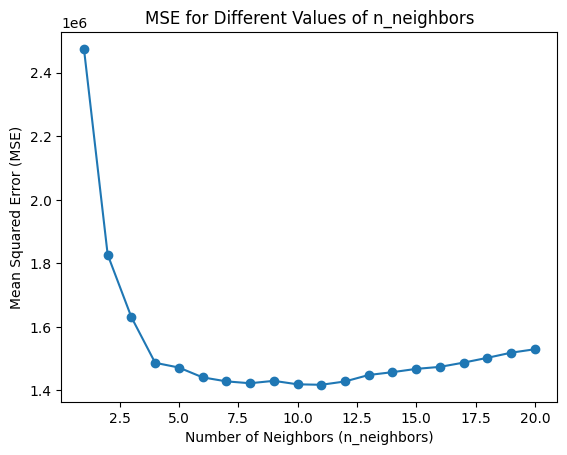

In [10]:
# Find the Best Value for n_neighbors

# Define a range of values for n_neighbors
n_neighbors_range = range(1, 21)

# Initialize variables to store the best n_neighbors and the corresponding lowest MSE
best_n_neighbors = None
lowest_mse = float('inf') #assigning a very high value as default
mse_values = []
best_mse = float('inf') #assigning a very high value as default
# Loop through different values of n_neighbors
for n_neighbors in range(1, 21):
    # Train the k-NN model
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = knn.predict(X_test)
    
    # Calculate the Mean Squared Error (MSE)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    
    # Update the best n_neighbors and best_mse if the current MSE is lower
    if mse < best_mse:
        best_mse = mse
        best_n_neighbors = n_neighbors


# Print the best n_neighbors and the corresponding lowest MSE


print(f"Best n_neighbors: {best_n_neighbors}")
print(f"Lowest Mean Squared Error: {best_mse}")
plt.plot(n_neighbors_range, mse_values, marker='o')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE for Different Values of n_neighbors')
plt.show()
